# IAA, Lab 2 : AI and Vision-based navigation
**Students: Emily Baquerizo & Kimberly Beyeler**

In [1]:
import os
import time
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

# Exploration des données

## Import des données

In [2]:
DATA_ROOT = r"C:\Users\Victus\Documents\duckietown\datasets"
CSV_PATH  = DATA_ROOT + r"\labels.csv"
IMG_DIR   = DATA_ROOT + r"\images"
print(f"Dataset prêt — {len(os.listdir(IMG_DIR))} images trouvées")

Dataset prêt — 25205 images trouvées


## Affichages des données

In [3]:
df = pd.read_csv(CSV_PATH)
print(len(df))
df.head()

25205


,timestamp,image_name,vel_left,vel_right
0,1.770648e+09,1770647880.149484.jpg,0.225903,0.216678
1,1.770648e+09,1770647880.196790.jpg,0.225806,0.216775
2,1.770648e+09,1770647880.232433.jpg,0.225529,0.217052
3,1.770648e+09,1770647880.248546.jpg,0.207938,0.234643
4,1.770648e+09,1770647880.297955.jpg,0.208268,0.234313


In [4]:
df[["vel_left", "vel_right"]].describe()

,vel_left,vel_right
count,25205.000000,25205.000000
mean,0.219207,0.223374
std,0.045192,0.045192
min,0.072393,0.089099
25%,0.190551,0.204908
50%,0.217278,0.225303
75%,0.237673,0.252030
max,0.353482,0.370188


## Visualisation des données

Text(0.5, 1.0, 'Distribution velocity right')

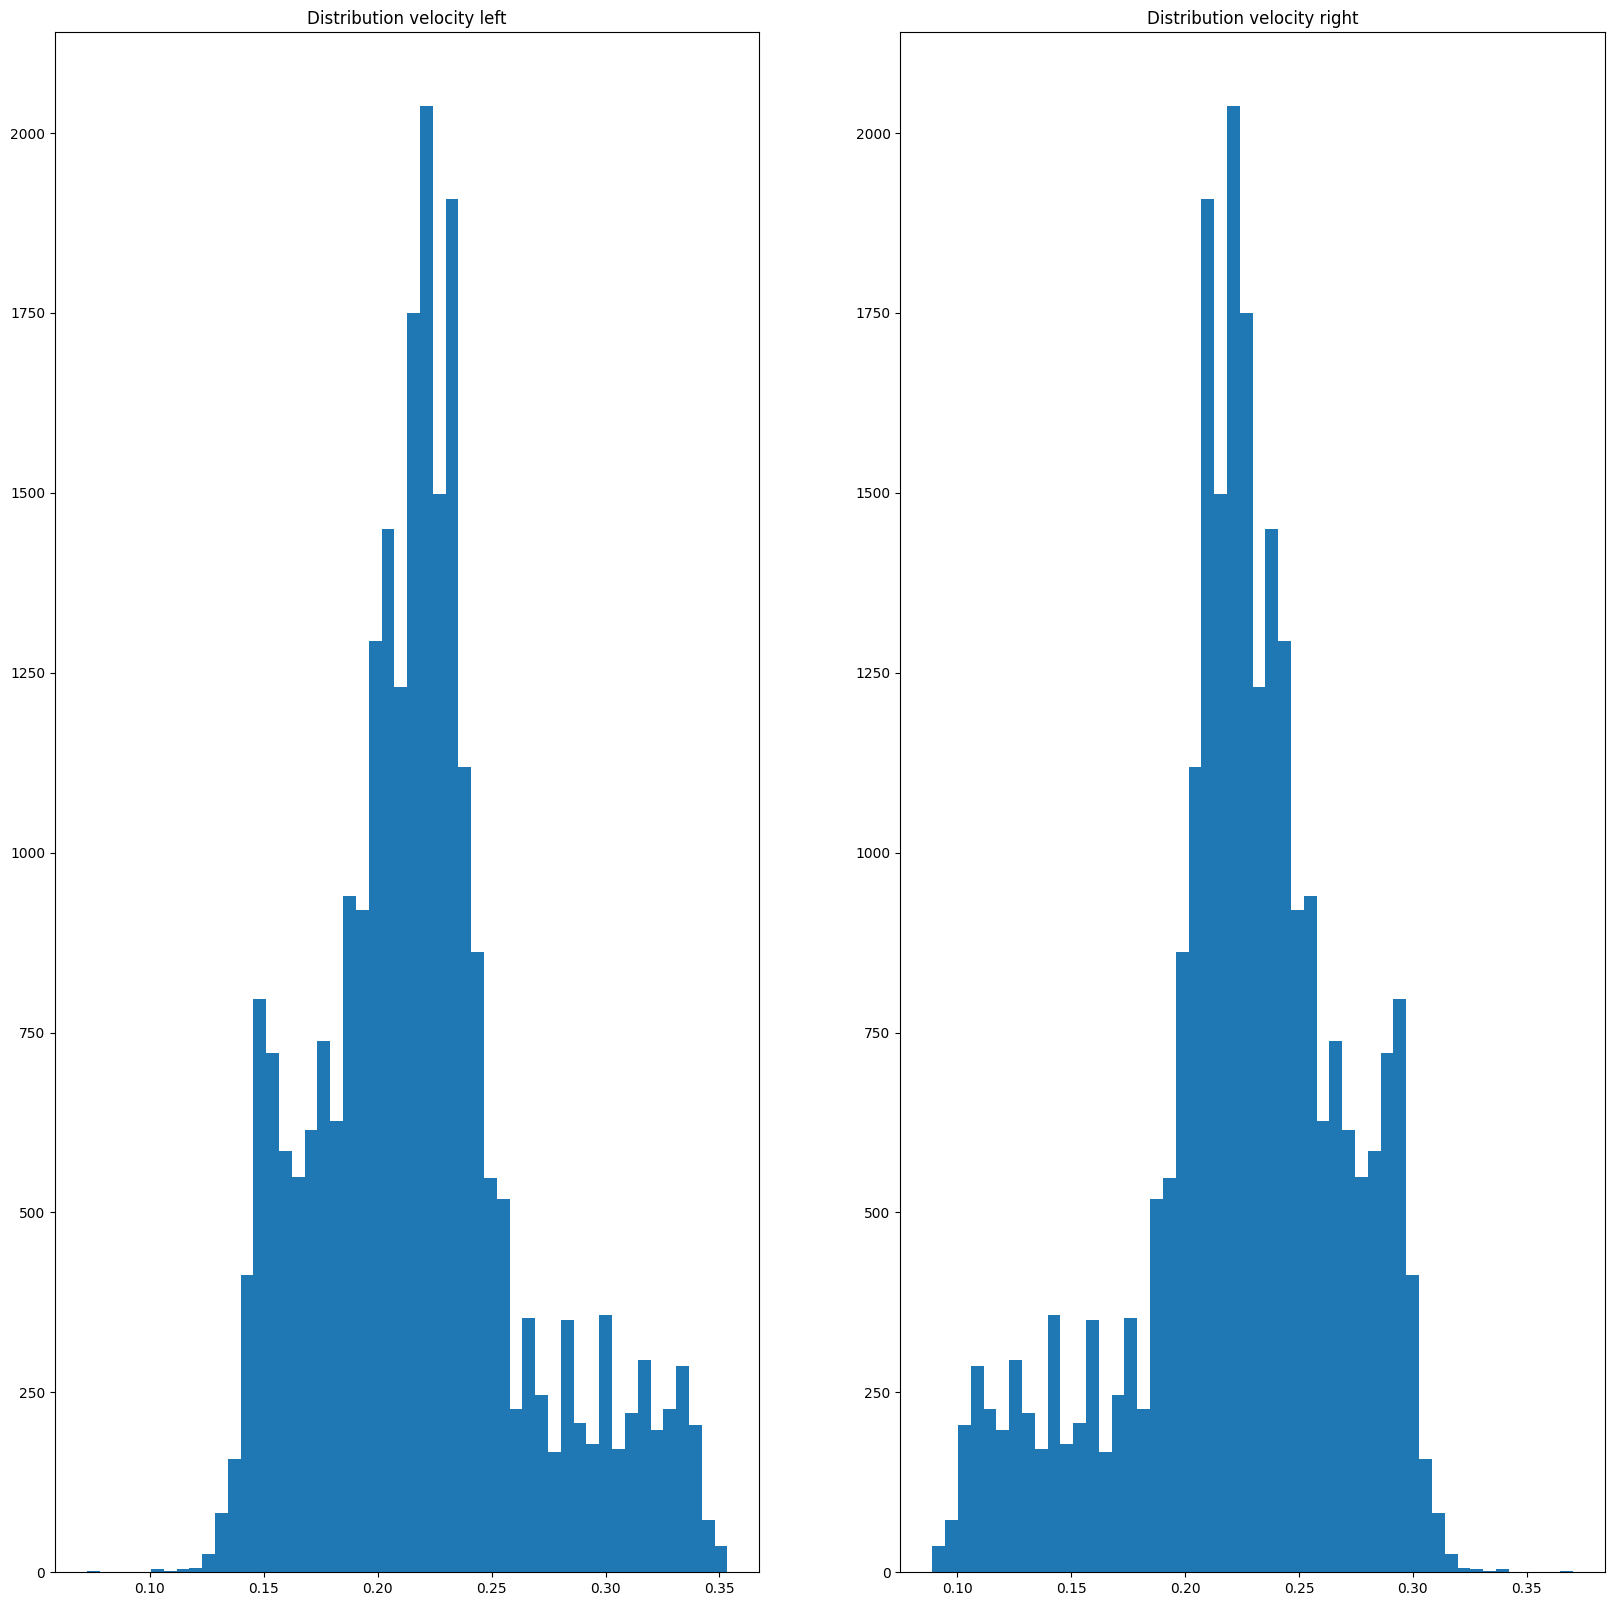

In [5]:
plt.figure(figsize=(20, 20))

plt.subplot(1,2,1)
plt.hist(df["vel_left"], bins=50)
plt.title("Distribution velocity left")

plt.subplot(1,2,2)
plt.hist(df["vel_right"], bins=50)
plt.title("Distribution velocity right")

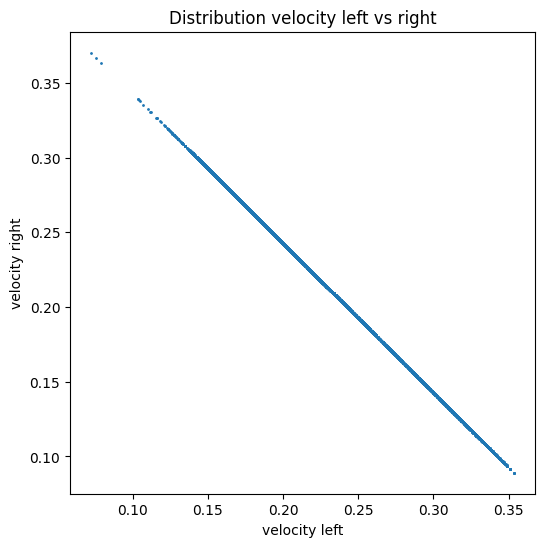

In [6]:
plt.figure(figsize=(6,6))
plt.scatter(df["vel_left"], df["vel_right"], s=1)
plt.title("Distribution velocity left vs right")
plt.xlabel("velocity left")
plt.ylabel("velocity right")
plt.show()


## Affichage des données

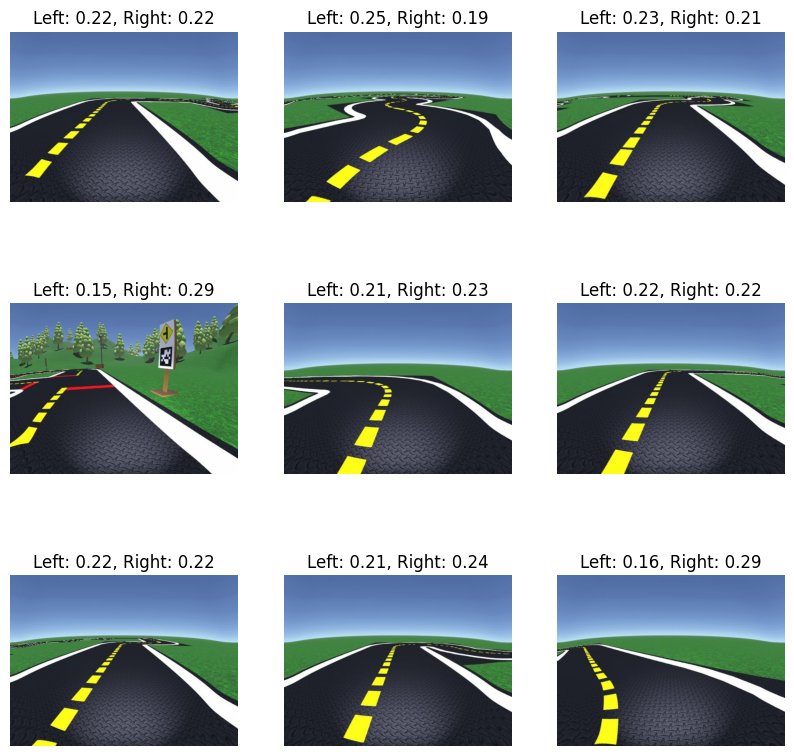

In [7]:
sample = df.sample(9)
plt.figure(figsize=(10,10))
for i, (_,row) in enumerate(sample.iterrows()):
  img = Image.open(f"{IMG_DIR}/{row.image_name}")
  plt.subplot(3, 3, i + 1)
  plt.imshow(img)
  plt.title(f"Left: {row.vel_left:.2f}, Right: {row.vel_right:.2f}")
  plt.axis("off")

# Modèle


In [8]:
# Transforms
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Dataset
class DuckieDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(f"{self.img_dir}/{row.image_name}").convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor([row.vel_left, row.vel_right], dtype=torch.float32)

# Split + DataLoaders
full_dataset = DuckieDataset(df, IMG_DIR, transform=train_tf)
n = len(full_dataset)
n_train, n_val = int(0.70*n), int(0.15*n)
n_test = n - n_train - n_val

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0, pin_memory=False)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 17643 | Val: 3780 | Test: 3782


## Construction du modèle

In [9]:
class DuckieNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        backbone = models.resnet18(weights=weights)
        for name, param in backbone.named_parameters():
            if "layer4" not in name and "fc" not in name:
                param.requires_grad = False
        in_features = backbone.fc.in_features
        backbone.fc = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )
        self.model = backbone

    def forward(self, x):
        return self.model(x)

    @staticmethod
    def init_and_load(checkpoint_path: str) -> "DuckieNet":
        model = DuckieNet(pretrained=False)
        checkpoint = torch.load(checkpoint_path, map_location="cpu")
        model.load_state_dict(checkpoint["model_state_dict"])
        model.eval()
        return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
model = DuckieNet(pretrained=True).to(device)
print(f"Output shape : {model(torch.randn(2,3,224,224).to(device)).shape}")

Device : cuda
Output shape : torch.Size([2, 2])


## Entrainement du modèle

In [10]:
CHECKPOINT_DIR = r"C:\Users\Victus\Documents\duckietown\checkpoints"
DRIVE_DIR      = r"C:\Users\Victus\Documents\duckietown\checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(DRIVE_DIR,      exist_ok=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_mae = 0.0, 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            loss  = criterion(preds, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            total_mae  += (preds - labels).abs().mean().item() * imgs.size(0)
    return total_loss / len(loader.dataset), total_mae / len(loader.dataset)

history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}
best_val_loss = float("inf")
NUM_EPOCHS = 20

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_mae = run_epoch(train_loader, train=True)
    vl_loss, vl_mae = run_epoch(val_loader,   train=False)
    scheduler.step(vl_loss)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_mae"].append(tr_mae)
    history["val_mae"].append(vl_mae)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {tr_loss:.6f} MAE: {tr_mae:.5f} | "
          f"Val Loss: {vl_loss:.6f} MAE: {vl_mae:.5f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    ckpt = {"epoch": epoch, "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(), "val_loss": vl_loss}
    torch.save(ckpt, os.path.join(CHECKPOINT_DIR, f"checkpoint_epoch{epoch:02d}.pt"))

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(ckpt, os.path.join(DRIVE_DIR, "best_model.pt"))
        print(f"  best_model.pt sauvegardé (val_loss={vl_loss:.6f})")

Epoch 01/20 | Train Loss: 0.005134 MAE: 0.04547 | Val Loss: 0.000765 MAE: 0.02100 | LR: 1.00e-03
  best_model.pt sauvegardé (val_loss=0.000765)
Epoch 02/20 | Train Loss: 0.001508 MAE: 0.02988 | Val Loss: 0.000604 MAE: 0.01790 | LR: 1.00e-03
  best_model.pt sauvegardé (val_loss=0.000604)
Epoch 03/20 | Train Loss: 0.000942 MAE: 0.02319 | Val Loss: 0.000537 MAE: 0.01651 | LR: 1.00e-03
  best_model.pt sauvegardé (val_loss=0.000537)
Epoch 04/20 | Train Loss: 0.000707 MAE: 0.01971 | Val Loss: 0.000573 MAE: 0.01691 | LR: 1.00e-03
Epoch 05/20 | Train Loss: 0.000601 MAE: 0.01788 | Val Loss: 0.000525 MAE: 0.01607 | LR: 1.00e-03
  best_model.pt sauvegardé (val_loss=0.000525)
Epoch 06/20 | Train Loss: 0.000577 MAE: 0.01743 | Val Loss: 0.000600 MAE: 0.01788 | LR: 1.00e-03
Epoch 07/20 | Train Loss: 0.000581 MAE: 0.01736 | Val Loss: 0.000516 MAE: 0.01561 | LR: 1.00e-03
  best_model.pt sauvegardé (val_loss=0.000516)
Epoch 08/20 | Train Loss: 0.000572 MAE: 0.01722 | Val Loss: 0.000547 MAE: 0.01670 | LR

In [11]:
# Dégeler toutes les couches
for param in model.parameters():
    param.requires_grad = True

# Fine-tuning avec LR plus petit
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

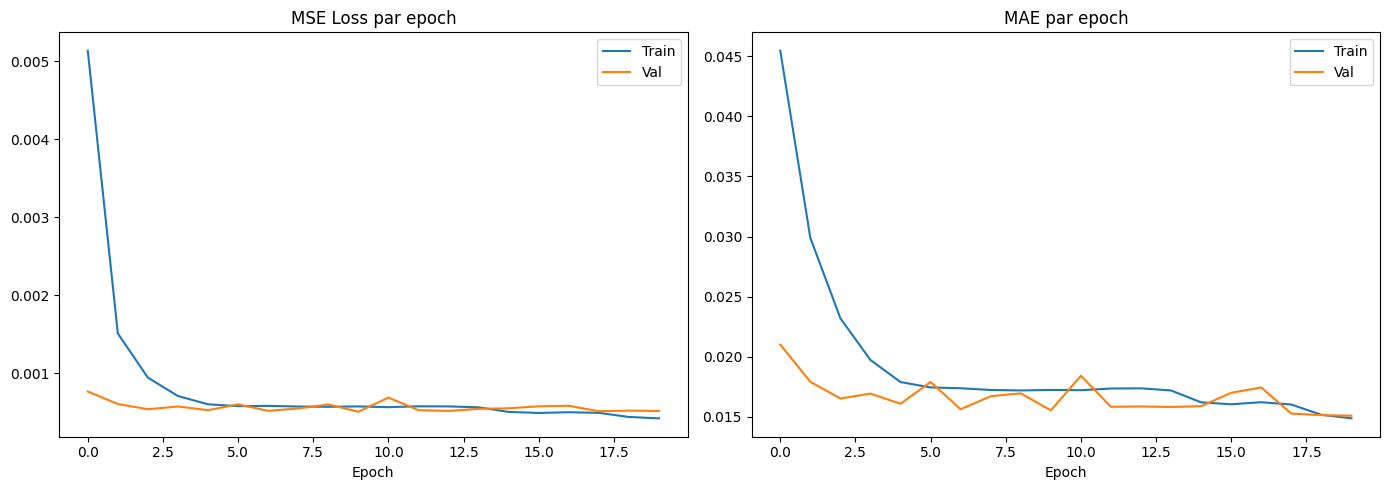

In [12]:
# Courbes de loss et MAE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"],   label="Val")
ax1.set_title("MSE Loss par epoch")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(history["train_mae"], label="Train")
ax2.plot(history["val_mae"],   label="Val")
ax2.set_title("MAE par epoch")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

In [13]:
# Évaluation finale sur le test set
test_loss, test_mae = run_epoch(test_loader, train=False)
print(f"Test MSE Loss : {test_loss:.6f}")
print(f"Test MAE      : {test_mae:.5f}")

Test MSE Loss : 0.000516
Test MAE      : 0.01522


In [14]:
best = DuckieNet.init_and_load(
    r"C:\Users\Victus\Documents\duckietown\checkpoints\best_model.pt"
)